# Ontario Life Churn Prediction Report

## Executive Summary

Ontario Life's case asks a practical question: which policyholders are most at risk of churn, what patterns explain that risk, and how should the company intervene before a cancellation happens.

This notebook uses a balanced logistic regression model as the final production-facing analysis because it is transparent, easy to explain, and directly supports threshold-based outreach. On a holdout sample, the model achieves an AUC-ROC of **0.6329**. At the operating threshold used in the final deck, **0.58**, the model reaches **78.8%** accuracy, **8.8%** precision, and **28.2%** recall for the churn class.

The business story is clear:
- Churn is relatively rare at **5.9%**, so raw accuracy alone is not enough.
- Churned customers have lower satisfaction, higher premiums, and longer tenure than retained customers.
- Risk rises materially across the customer lifecycle, from **2.42%** in years 0 to 2 to **8.40%** after year 10.
- A ranked risk score supports targeted triage. The top 30% of customers by predicted risk capture **45.3%** of churners in the holdout set.
- The threshold structure from the final slide deck is reproducible in the holdout sample: **52** customers at risk >= 0.75, **100** at risk >= 0.70, and **373** at risk >= 0.58.

The conclusion is not that the model is perfect. The conclusion is that it is operationally useful. Ontario Life should use it to prioritize service recovery, channel-specific outreach, and lifecycle-based retention campaigns.


## Problem Definition

Ontario Life wants to reduce churn in its life insurance portfolio by moving from reactive retention to early intervention. This means turning customer, policy, and experience data into a usable early-warning system.

The final notebook is designed to answer four business questions:

1. Which customers are most at risk of churn?
2. What data patterns explain that risk?
3. How should Ontario Life prioritize retention effort?
4. How should success be measured once the program launches?

Two principles guide the analysis:
- Use `churn_reason` for descriptive insight only, never as a predictive feature.
- Favor clarity and business action over model complexity.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from churn_utils import (
    load_data,
    build_feature_matrix,
    train_balanced_logistic_regression,
    threshold_table,
    coefficient_table,
    gains_table,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
SAVE_FIGURES = True
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
df = load_data(PROJECT_ROOT / "data" / "Insurance Churn Dataset.xlsx")
df.head()

,customer_id,country,province,age,issue_age,gender,tenure_year,premium_amount,satisfaction_score,channel,marital_status,income_bracket,employment_status,number_of_dependents,health_status,policy_term,premium_frequency,churn?,churn_reason,annual_premium,clv_proxy
0,CA200000,Canada,Nova Scotia,42,26,Female,16,83.43,55.3,Agent,Single,50-75k,Employed,0,Preferred,Whole Life,Monthly,0,No Churn,1001.16,16018.56
1,CA200001,Canada,Ontario,80,37,Female,43,1321.92,85.5,Broker,Married,25-50k,Retired,2,Standard,Whole Life,Annual,0,No Churn,1321.92,56842.56
2,CA200002,Canada,Ontario,80,39,Male,41,1380.24,52.1,Agent,Married,25-50k,Retired,1,Standard,Whole Life,Annual,1,Premiums Unaffordable,1380.24,56589.84
3,CA200003,Canada,Ontario,21,18,Female,3,546.05,54.3,Agent,Divorced,<25k,Employed,2,Preferred Plus,Whole Life,Annual,0,No Churn,546.05,1638.15
4,CA200004,Canada,Quebec,57,40,Male,17,50.75,67.6,Agent,Married,50-75k,Employed,1,Standard,T20,Monthly,0,No Churn,609.00,10353.00


## Data Overview

The dataset contains one row per policyholder. It includes demographic variables, policy attributes, acquisition channel, payment pattern, customer satisfaction, and the target label `churn?`.

For predictive modeling, the most important distinction is between variables available before churn and variables only known after churn. `churn_reason` falls into the second group, so it is excluded from the model.


In [3]:
overview = pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "overall_churn_rate": [df["churn?"].mean()],
    "churn_count": [df["churn?"].sum()],
    "non_churn_count": [(df["churn?"] == 0).sum()],
})
overview

,rows,columns,overall_churn_rate,churn_count,non_churn_count
0,10000,21,0.0587,587,9413


In [4]:
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "missing_values": df.isna().sum().values,
})
data_dictionary

,column,dtype,missing_values
0,customer_id,object,0
1,country,object,0
2,province,object,0
3,age,int64,0
4,issue_age,int64,0
5,gender,object,0
6,tenure_year,int64,0
7,premium_amount,float64,0
8,satisfaction_score,float64,0
9,channel,object,0


### What this means

The target is imbalanced. Only **5.9%** of customers churn. That matters because a naive model could post strong accuracy while missing most churners. The rest of the notebook therefore focuses on ranking quality, threshold trade-offs, and business prioritization, not on accuracy alone.


## Exploratory Data Analysis

The goal of the EDA is not to produce charts for their own sake. The goal is to identify business patterns Ontario Life can act on.

We will focus on:
- churn reason mix
- satisfaction as an early-warning signal
- lifecycle and tenure effects
- segment differences across channel, policy term, and health status


In [5]:
reason_mix = (
    df.loc[df["churn?"] == 1, "churn_reason"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename("share_of_churners_pct")
    .reset_index()
    .rename(columns={"index": "churn_reason"})
)
reason_mix

,churn_reason,share_of_churners_pct
0,Better Offer Elsewhere,33.6
1,Premiums Unaffordable,29.0
2,No Longer Needed,21.3
3,Poor Customer Service,16.2


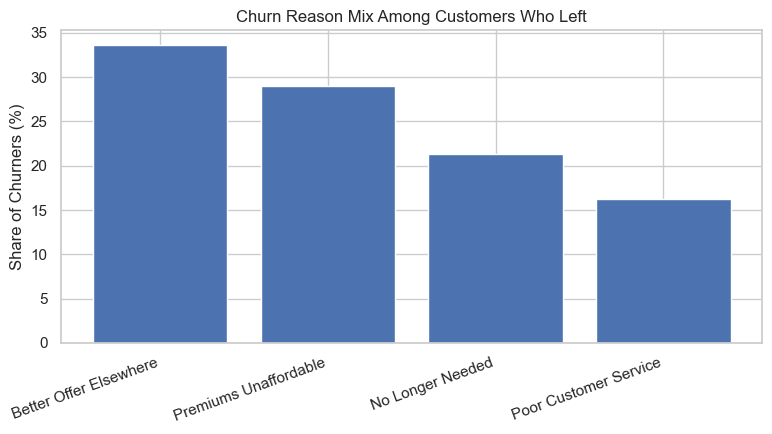

In [6]:
plt.figure(figsize=(8, 4.5))
plt.bar(reason_mix["churn_reason"], reason_mix["share_of_churners_pct"])
plt.title("Churn Reason Mix Among Customers Who Left")
plt.ylabel("Share of Churners (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(FIG_DIR / "churn_reasons.png", dpi=200)
plt.show()


### Business interpretation

The raw reason mix explains why pure predictive modeling is only part of the answer.

The largest stated reasons are:
- Better Offer Elsewhere: **33.6%**
- Premiums Unaffordable: **29.0%**
- No Longer Needed: **21.3%**
- Poor Customer Service: **16.2%**

What this means:
- Churn is partly competitive, partly affordability-driven, and partly lifecycle-driven.
- Ontario Life should not use one generic save script for every flagged customer.

What Ontario Life should do:
- Use the model to find who to contact.
- Use churn reason patterns to decide how to contact them and what offer to present.


In [7]:
satisfaction_summary = (
    df.groupby("churn?")["satisfaction_score"]
    .agg(["median", "mean"])
    .rename(index={0: "Retained", 1: "Churned"})
)
satisfaction_summary

,median,mean
churn?,,
Retained,68.8,68.398874
Churned,64.0,64.407325


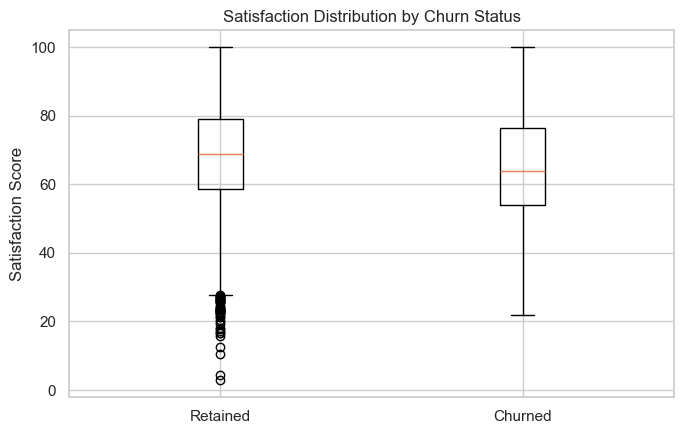

In [8]:
plt.figure(figsize=(7, 4.5))
plt.boxplot(
    [
        df.loc[df["churn?"] == 0, "satisfaction_score"],
        df.loc[df["churn?"] == 1, "satisfaction_score"],
    ],
    tick_labels=["Retained", "Churned"],
)
plt.title("Satisfaction Distribution by Churn Status")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(FIG_DIR / "satisfaction_gap.png", dpi=200)
plt.show()


In [9]:
df["sat_band"] = pd.cut(
    df["satisfaction_score"],
    bins=[0, 50, 65, 80, 100],
    labels=["0-50", "50-65", "65-80", "80-100"],
    include_lowest=True,
)

sat_band_rates = (
    df.groupby("sat_band", observed=False)["churn?"]
    .mean()
    .mul(100)
    .round(2)
    .rename("churn_rate_pct")
)
sat_band_rates

sat_band
0-50      9.83
50-65     6.43
65-80     4.79
80-100    4.78
Name: churn_rate_pct, dtype: float64

### Business interpretation

Satisfaction is one of the clearest early-warning signals in the portfolio.

Observed pattern:
- Median satisfaction among retained customers is **68.8**
- Median satisfaction among churned customers is **64.0**
- Churn rate is **9.83%** in the lowest satisfaction band and falls to roughly **4.79%** in the 65 to 80 band

What this means:
- A drop in satisfaction is not noise. It is a practical trigger for intervention.
- Ontario Life does not need to wait for a cancellation request to act.

What Ontario Life should do:
- Create a satisfaction-triggered save workflow.
- Flag customers whose score drops into the bottom two bands.
- Route high-premium, low-satisfaction customers to live service recovery first.


In [10]:
df["tenure_band"] = pd.cut(
    df["tenure_year"],
    bins=[-1, 2, 5, 10, 100],
    labels=["0-2 years", "3-5 years", "6-10 years", "10+ years"],
)

tenure_summary = (
    df.groupby("tenure_band", observed=False)["churn?"]
    .mean()
    .mul(100)
    .round(2)
    .rename("churn_rate_pct")
)
tenure_summary

tenure_band
0-2 years     2.42
3-5 years     4.33
6-10 years    6.24
10+ years     8.40
Name: churn_rate_pct, dtype: float64

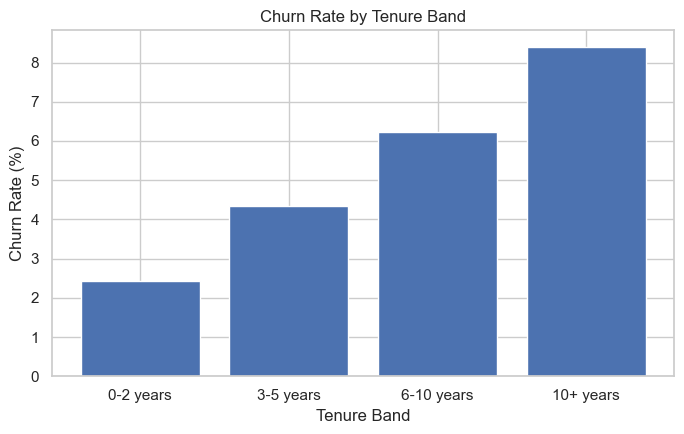

In [11]:
plt.figure(figsize=(7, 4.5))
plt.bar(tenure_summary.index.astype(str), tenure_summary.values)
plt.title("Churn Rate by Tenure Band")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(FIG_DIR / "tenure_band_churn.png", dpi=200)
plt.show()


In [12]:
segment_summary = {
    "channel": df.groupby("channel")["churn?"].mean().mul(100).round(2).sort_values(ascending=False),
    "policy_term": df.groupby("policy_term")["churn?"].mean().mul(100).round(2).sort_values(ascending=False),
    "health_status": df.groupby("health_status")["churn?"].mean().mul(100).round(2).sort_values(ascending=False),
}
segment_summary

{'channel': channel
 Online     6.42
 Partner    6.23
 Broker     5.61
 Agent      5.48
 Name: churn?, dtype: float64,
 'policy_term': policy_term
 Whole Life    8.30
  T10          4.70
 T20           4.64
 Name: churn?, dtype: float64,
 'health_status': health_status
 Standard          7.00
 Preferred         6.46
 Rated             5.94
 Preferred Plus    2.99
 Name: churn?, dtype: float64}

### Business interpretation

Risk changes across the lifecycle.

Observed pattern:
- Churn rate rises from **2.42%** in years 0 to 2
- to **4.33%** in years 3 to 5
- to **6.24%** in years 6 to 10
- to **8.40%** after year 10

Additional segment signals:
- Highest channel churn rates are currently **Online (6.42%)** and **Partner (6.23%)**
- **Whole Life** policies churn at **8.30%**, well above the term products
- Customers in **Preferred Plus** have the lowest churn rate at **2.99%**

What this means:
- Long tenure does not automatically equal loyalty.
- Lifecycle campaigns matter. A customer at year 12 should not receive the same messaging as a customer in year 1.
- Channel differences are real, but they should be described as behavioral differences, not assumed hierarchy, unless the data supports it.

What Ontario Life should do:
- Build milestone-based retention campaigns around key tenure windows.
- Review Whole Life positioning and value communication.
- Design channel-specific playbooks instead of one generic workflow.


## Feature Engineering

The final model uses only fields that would be available before churn happens.

Key engineered feature:
- `annual_premium = premium_amount * premium_frequency multiplier`
- `clv_proxy = annual_premium * tenure_year`

Modeling choices:
- one-hot encode `channel`, `health_status`, and `policy_term`
- standardize numeric features
- exclude identifiers and `churn_reason`


In [13]:
X, y, feature_cols = build_feature_matrix(df)
artifacts = train_balanced_logistic_regression(X, y, random_state=42)

y_test = artifacts["y_test"]
y_prob = artifacts["y_prob"]
model = artifacts["model"]
X_test = artifacts["X_test"]

X.shape, y.shape


((10000, 14), (10000,))

## Modeling

A balanced logistic regression is used for the final project.

Why logistic regression:
- it matches the final presentation story
- it is easy to explain to business stakeholders
- it produces a risk score that supports ranking and threshold design
- it avoids the black-box feel that often weakens consulting-style portfolio work


In [14]:
thresholds = [0.50, 0.58, 0.70, 0.75]
threshold_results = threshold_table(y_test, y_prob, thresholds)
threshold_results.round(4)

,threshold,flagged,accuracy,auc_roc,average_precision,precision,recall,tp,fp,tn,fn
0,0.50,783,0.6180,0.6329,0.098,0.0868,0.5812,68,715,1168,49
1,0.58,373,0.7880,0.6329,0.098,0.0885,0.2821,33,340,1543,84
2,0.70,100,0.9065,0.6329,0.098,0.1500,0.1282,15,85,1798,102
3,0.75,52,0.9255,0.6329,0.098,0.1923,0.0855,10,42,1841,107


## Model Performance

The core ranking metric is AUC-ROC, not raw accuracy. On the holdout sample:

- AUC-ROC: **0.6329**
- Average Precision: **0.0980**
- Accuracy at threshold 0.58: **78.8%**
- Precision at threshold 0.58: **8.8%**
- Recall at threshold 0.58: **28.2%**

What this means:
- The model is not strong enough to automate an accept or reject decision.
- The model is strong enough to prioritize outreach and concentrate risk into a smaller list.
- Threshold choice changes the operating model. Higher thresholds reduce volume and improve precision. Lower thresholds expand coverage.

What Ontario Life should do:
- Treat the model as a ranking engine.
- Pair risk thresholds with outreach cost tiers.
- Re-estimate thresholds once pilot save rates and contact costs become available.


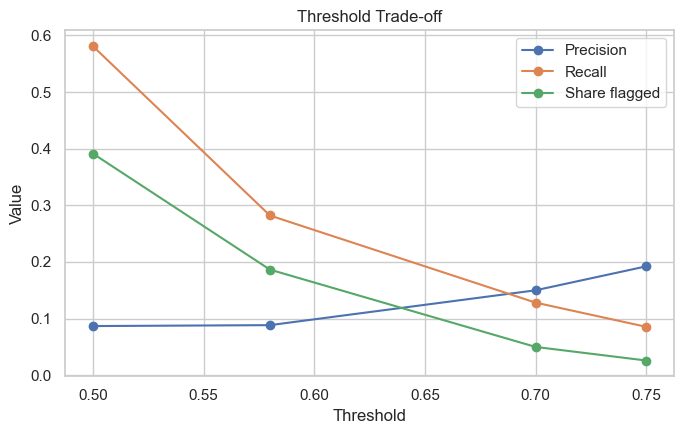

In [15]:
threshold_plot = threshold_results.copy()

plt.figure(figsize=(7, 4.5))
plt.plot(threshold_plot["threshold"], threshold_plot["precision"], marker="o", label="Precision")
plt.plot(threshold_plot["threshold"], threshold_plot["recall"], marker="o", label="Recall")
plt.plot(
    threshold_plot["threshold"],
    threshold_plot["flagged"] / len(y_test),
    marker="o",
    label="Share flagged",
)
plt.title("Threshold Trade-off")
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(FIG_DIR / "threshold_tradeoff.png", dpi=200)
plt.show()


## Key Drivers of Churn

Coefficient interpretation should be directional, not causal. This is especially important here because `clv_proxy` overlaps mechanically with premium and tenure.

The safest way to read the model is:
- use coefficients for sign and relative emphasis
- use the EDA for business grounding
- avoid claiming causality from one coefficient alone


In [16]:
coef_df = coefficient_table(model, feature_cols)
coef_df.head(12)

,feature,coefficient,abs_coefficient
1,tenure_year,0.422338,0.422338
5,clv_proxy,-0.279297,0.279297
3,satisfaction_score,-0.242335,0.242335
9,health_status_Preferred Plus,-0.233541,0.233541
13,policy_term_Whole Life,0.172541,0.172541
2,premium_amount,0.108470,0.108470
12,policy_term_T20,-0.089958,0.089958
7,channel_Online,0.085882,0.085882
11,health_status_Standard,0.085666,0.085666
10,health_status_Rated,-0.029736,0.029736


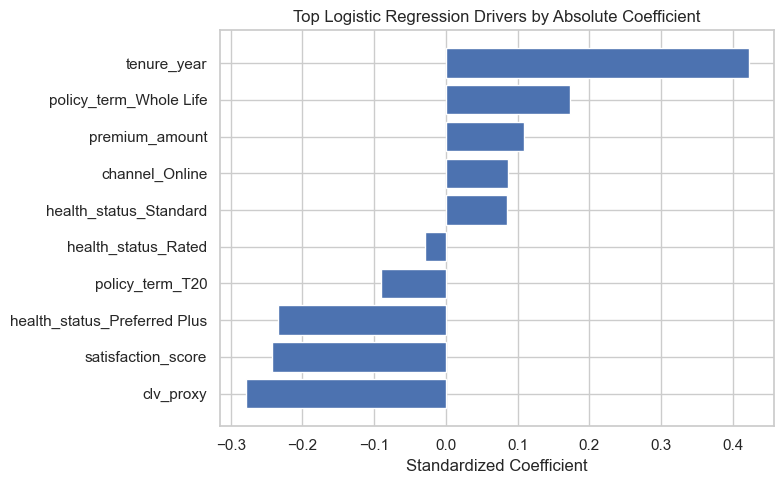

In [17]:
top_coef = coef_df.head(10).sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.title("Top Logistic Regression Drivers by Absolute Coefficient")
plt.xlabel("Standardized Coefficient")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(FIG_DIR / "logistic_drivers.png", dpi=200)
plt.show()


### Business interpretation

Most important directional signals in the final model:
- Higher **tenure_year** raises risk
- Higher **premium_amount** raises risk
- Higher **satisfaction_score** lowers risk
- **health_status_Preferred Plus** lowers risk
- **policy_term_Whole Life** raises risk relative to the reference category

What this means:
- The deck's core story holds up. Churn risk is tied to lifecycle, price exposure, and customer experience.
- Satisfaction is not the only lever. High-value, longer-tenured customers also need proactive attention.

What Ontario Life should do:
- Combine experience-based triggers with lifecycle and value-at-risk rules.
- Protect expensive, long-tenured accounts with proactive policy reviews.
- Investigate why Whole Life customers show higher churn in this sample.


## Threshold Optimization and Ranking Strategy

Thresholds convert probabilities into action queues.

The final deck used three thresholds:
- 0.75 for high-touch intervention
- 0.70 for personalized digital plus assisted follow-up
- 0.58 for broader low-cost outreach and monitoring

That structure is useful because it connects model confidence to contact cost.


In [18]:
gains = gains_table(y_test, y_prob)

capture_points = []
for pct in [0.10, 0.20, 0.30]:
    idx = int(len(gains) * pct) - 1
    capture_points.append({
        "top_customer_share": pct,
        "captured_churner_share": gains.loc[idx, "cum_churner_pct"],
    })

capture_df = pd.DataFrame(capture_points)
capture_df

,top_customer_share,captured_churner_share
0,0.1,0.179487
1,0.2,0.299145
2,0.3,0.452991


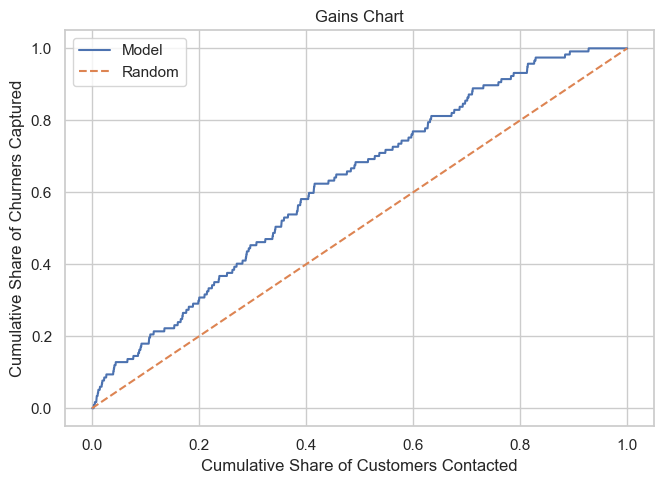

In [19]:
plt.figure(figsize=(6.8, 5))
plt.plot(gains["cum_customer_pct"], gains["cum_churner_pct"], label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("Gains Chart")
plt.xlabel("Cumulative Share of Customers Contacted")
plt.ylabel("Cumulative Share of Churners Captured")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(FIG_DIR / "gains_chart.png", dpi=200)
plt.show()


### Business interpretation

The gains chart shows the model is useful because it concentrates churners into a smaller share of the customer base.

On the holdout sample:
- Top 10% of customers by risk capture **17.9%** of churners
- Top 20% capture **29.9%**
- Top 30% capture **45.3%**

What this means:
- The model beats random outreach.
- Ontario Life can plan outreach capacity instead of contacting everyone.

What Ontario Life should do:
- Use threshold 0.75 when retention capacity is scarce and high-touch saves are expensive.
- Use threshold 0.70 when the team can support a medium-sized monthly contact list.
- Use threshold 0.58 when Ontario Life wants broader, lower-cost digital coverage.


## Tiered Retention Strategy

The strongest part of the final deck is not the model. It is the operating design built around the model.

We keep that structure, but ground it in the actual holdout counts.


In [20]:
scored_test = df.loc[X_test.index].copy()
scored_test["risk_score"] = y_prob

tiers = []
for tier_name, mask in {
    "Tier 1: risk >= 0.75": scored_test["risk_score"] >= 0.75,
    "Tier 2: 0.70 <= risk < 0.75": (scored_test["risk_score"] >= 0.70) & (scored_test["risk_score"] < 0.75),
    "Tier 3: 0.58 <= risk < 0.70": (scored_test["risk_score"] >= 0.58) & (scored_test["risk_score"] < 0.70),
}.items():
    seg = scored_test.loc[mask]
    tiers.append({
        "tier": tier_name,
        "customers": len(seg),
        "actual_churn_rate_in_segment": seg["churn?"].mean(),
        "median_premium": seg["premium_amount"].median(),
        "median_satisfaction": seg["satisfaction_score"].median(),
        "median_tenure": seg["tenure_year"].median(),
    })

tier_df = pd.DataFrame(tiers)
tier_df.round(3)

,tier,customers,actual_churn_rate_in_segment,median_premium,median_satisfaction,median_tenure
0,Tier 1: risk >= 0.75,52,0.192,933.605,52.45,46.0
1,Tier 2: 0.70 <= risk < 0.75,48,0.104,1188.000,55.30,26.0
2,Tier 3: 0.58 <= risk < 0.70,273,0.066,808.500,62.00,16.0


### Recommended intervention design

Tier 1, risk >= 0.75
- Smallest list, highest confidence
- Use senior retention specialists
- Lead with service recovery, affordability review, and policy review
- Appropriate for premium relief, coverage redesign, or white-glove outreach

Tier 2, risk 0.70 to 0.75
- Medium list with meaningful risk concentration
- Use personalized email and SMS with fast escalation rules
- Offer a policy review link and a service check-in
- Route negative responses to live follow-up

Tier 3, risk 0.58 to 0.70
- Largest flagged group
- Use low-cost nudges, value reinforcement, and continued monitoring
- Reserve expensive save actions for customers whose risk score rises further

What this means:
- Retention cost should rise with risk confidence.
- The same save action should not be used on every flagged customer.


## Business Impact and ROI Framework

The raw case data supports triage value. It does not support direct ROI calculation.

This distinction is important. Many school projects overstate business impact. A stronger consulting deliverable separates:
- what the model proves now
- what Ontario Life still needs to measure in the pilot


In [21]:
base_rate = y_test.mean()

capacity_examples = pd.DataFrame([
    {
        "outreach_capacity": 52,
        "threshold": 0.75,
        "expected_churners_found_by_model": int(threshold_results.loc[threshold_results["threshold"] == 0.75, "tp"].iloc[0]),
        "expected_churners_found_randomly": round(52 * base_rate, 1),
    },
    {
        "outreach_capacity": 100,
        "threshold": 0.70,
        "expected_churners_found_by_model": int(threshold_results.loc[threshold_results["threshold"] == 0.70, "tp"].iloc[0]),
        "expected_churners_found_randomly": round(100 * base_rate, 1),
    },
    {
        "outreach_capacity": 373,
        "threshold": 0.58,
        "expected_churners_found_by_model": int(threshold_results.loc[threshold_results["threshold"] == 0.58, "tp"].iloc[0]),
        "expected_churners_found_randomly": round(373 * base_rate, 1),
    },
])

capacity_examples

,outreach_capacity,threshold,expected_churners_found_by_model,expected_churners_found_randomly
0,52,0.75,10,3.0
1,100,0.70,15,5.9
2,373,0.58,33,21.8


### Business interpretation

What the model proves now:
- It improves targeting efficiency versus random outreach.
- It supports staffing and queue design.
- It provides a rational basis for tiered intervention cost.

What the model does not prove yet:
- save rate after intervention
- cost per save
- retained premium
- incremental ROI

What Ontario Life should measure in the pilot:
1. Contact rate by tier
2. Save rate by tier
3. Cost per outreach and cost per save
4. Retained premium after intervention
5. Incremental lift versus a holdout control group

The slide deck's rollout KPIs such as churn reduction, save rate, and ROI should be treated as operational targets for the pilot, not as outcomes already measured from this dataset.


## Conclusion

This project turns a churn case into a usable operating design.

Final takeaways:
- The balanced logistic regression model is the right final model because it supports transparent risk ranking and threshold design.
- The strongest business signals are lower satisfaction, longer tenure, higher premiums, and specific policy and health segments.
- The model is best used as a triage engine, not as a perfect classifier.
- Thresholds are where the analytics becomes operational.
- The most credible next step is a controlled pilot that measures save rate, cost per save, and retained premium by tier.
